In [27]:
import pandas as pd
import numpy as np

## Data prep

In [28]:
tax = pd.read_csv("/home/gamorten/Microbiome_Health/data/taxonomy_correlation_input.csv")
tax_subset = tax.iloc[:, -4:]
tax_X = tax_subset.pivot(index='Sample', columns = 'taxa_label', values = 'relative_abundance')
tax_X.head()

taxa_label,Chitinophaga niabensis,Chryseobacterium lactis,Dehalobacterium formicoaceticum,Halobacillus sp. ACCC02827,Lysinibacillus agricola,Lysinibacillus fusiformis,Oceanobacillus sp. FSL K6-0127,Sphingobacterium faecium,Sphingobacterium lactis,Sphingobacterium sp. UGAL515B_05
Sample,,,,,,,,,,
S00JD-0001,2.486018,2.169364,1.649624,2.976498,3.320917,1.323183,1.648145,1.146313,1.031476,0.901445
S00JD-0002,1.930040,2.207590,1.255482,2.643225,2.420246,1.115855,1.915643,0.261722,0.858793,0.334873
S00JD-0003,1.880565,7.029452,1.222752,3.059599,2.875586,0.970405,2.640897,0.672856,0.754086,0.283969
S00JD-0004,1.888107,2.628466,1.116311,5.471571,2.613867,3.951463,5.055587,2.204079,0.853461,0.734271
S00JD-0005,1.907137,2.377657,1.464253,2.556144,2.778882,0.992233,2.541289,0.782743,1.194705,0.806969


In [29]:
func = pd.read_csv("/home/gamorten/Microbiome_Health/data/functional_input.csv")
func_subset = func[['Pathway', 'Abundance', 'Sample', 'Group.y']]
func_X = func_subset.pivot_table(index = 'Sample', columns = 'Pathway', values = 'Abundance')
func_X.head()

Pathway,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,METH-ACETATE-PWY: methanogenesis from acetate,PANTO-PWY: phosphopantothenate biosynthesis I,PHOSLIPSYN-PWY: superpathway of phospholipid biosynthesis I (bacteria),PWY-5695: inosine 5'-phosphate degradation,PWY-6527: stachyose degradation,PWY-6629: superpathway of L-tryptophan biosynthesis,PWY-6703: preQ0 biosynthesis,PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing),TRPSYN-PWY: L-tryptophan biosynthesis
Sample,,,,,,,,,,
S00JD-0001,0.000235,0.000098,0.000318,0.000232,0.000437,0.000152,0.000317,0.000312,0.000480,0.000239
S00JD-0002,0.000081,0.000055,0.000258,0.000185,0.000384,0.000213,0.000380,0.000127,0.000447,0.000276
S00JD-0003,0.000070,0.000069,0.000329,0.000145,0.000368,0.000257,0.000343,0.000167,0.000358,0.000221
S00JD-0004,0.000002,0.000000,0.000385,0.000261,0.000484,0.000236,0.000421,0.000283,0.000315,0.000381
S00JD-0005,0.000103,0.000066,0.000421,0.000190,0.000428,0.000210,0.000406,0.000270,0.000437,0.000316


In [30]:
X_old = pd.merge(func_X, tax_X, on = 'Sample')
X_old.head()

,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,METH-ACETATE-PWY: methanogenesis from acetate,PANTO-PWY: phosphopantothenate biosynthesis I,PHOSLIPSYN-PWY: superpathway of phospholipid biosynthesis I (bacteria),PWY-5695: inosine 5'-phosphate degradation,PWY-6527: stachyose degradation,PWY-6629: superpathway of L-tryptophan biosynthesis,PWY-6703: preQ0 biosynthesis,PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing),TRPSYN-PWY: L-tryptophan biosynthesis,Chitinophaga niabensis,Chryseobacterium lactis,Dehalobacterium formicoaceticum,Halobacillus sp. ACCC02827,Lysinibacillus agricola,Lysinibacillus fusiformis,Oceanobacillus sp. FSL K6-0127,Sphingobacterium faecium,Sphingobacterium lactis,Sphingobacterium sp. UGAL515B_05
Sample,,,,,,,,,,,,,,,,,,,,
S00JD-0001,0.000235,0.000098,0.000318,0.000232,0.000437,0.000152,0.000317,0.000312,0.000480,0.000239,2.486018,2.169364,1.649624,2.976498,3.320917,1.323183,1.648145,1.146313,1.031476,0.901445
S00JD-0002,0.000081,0.000055,0.000258,0.000185,0.000384,0.000213,0.000380,0.000127,0.000447,0.000276,1.930040,2.207590,1.255482,2.643225,2.420246,1.115855,1.915643,0.261722,0.858793,0.334873
S00JD-0003,0.000070,0.000069,0.000329,0.000145,0.000368,0.000257,0.000343,0.000167,0.000358,0.000221,1.880565,7.029452,1.222752,3.059599,2.875586,0.970405,2.640897,0.672856,0.754086,0.283969
S00JD-0004,0.000002,0.000000,0.000385,0.000261,0.000484,0.000236,0.000421,0.000283,0.000315,0.000381,1.888107,2.628466,1.116311,5.471571,2.613867,3.951463,5.055587,2.204079,0.853461,0.734271
S00JD-0005,0.000103,0.000066,0.000421,0.000190,0.000428,0.000210,0.000406,0.000270,0.000437,0.000316,1.907137,2.377657,1.464253,2.556144,2.778882,0.992233,2.541289,0.782743,1.194705,0.806969


In [31]:
meta = pd.read_csv("/home/gamorten/Microbiome_Health/metadata/metadata.csv")
# meta_subset = meta[['MBI Sample ID', 'Group', 'Hypertension', 'GDM']]
meta_subset = meta[['MBI Sample ID', 'Group']]
meta_subset.rename(columns = {'MBI Sample ID':"Sample"},inplace=True )
meta_subset['Group'] = meta_subset['Group'].map({'Case': 1, 'Control': 0})
y_old = meta_subset
y_old.head()

/tmp/ipykernel_850898/3488944293.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_subset.rename(columns = {'MBI Sample ID':"Sample"},inplace=True )
/tmp/ipykernel_850898/3488944293.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_subset['Group'] = meta_subset['Group'].map({'Case': 1, 'Control': 0})


,Sample,Group
0,S00NO-0001,0
1,S00NO-0002,1
2,S00NO-0003,0
3,S00NO-0004,0
4,S00NO-0005,0


## Prediction experiments
Using both taxonomic and functional profiles

In [32]:
full = pd.merge(X_old, y_old, on = 'Sample')

X = full.drop(columns=['Sample', 'Group'])
y = full['Group']
full.head()
X.head()
# y.head()

,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,METH-ACETATE-PWY: methanogenesis from acetate,PANTO-PWY: phosphopantothenate biosynthesis I,PHOSLIPSYN-PWY: superpathway of phospholipid biosynthesis I (bacteria),PWY-5695: inosine 5'-phosphate degradation,PWY-6527: stachyose degradation,PWY-6629: superpathway of L-tryptophan biosynthesis,PWY-6703: preQ0 biosynthesis,PWY0-1586: peptidoglycan maturation (meso-diaminopimelate containing),TRPSYN-PWY: L-tryptophan biosynthesis,Chitinophaga niabensis,Chryseobacterium lactis,Dehalobacterium formicoaceticum,Halobacillus sp. ACCC02827,Lysinibacillus agricola,Lysinibacillus fusiformis,Oceanobacillus sp. FSL K6-0127,Sphingobacterium faecium,Sphingobacterium lactis,Sphingobacterium sp. UGAL515B_05
0,0.000235,0.000098,0.000318,0.000232,0.000437,0.000152,0.000317,0.000312,0.000480,0.000239,2.486018,2.169364,1.649624,2.976498,3.320917,1.323183,1.648145,1.146313,1.031476,0.901445
1,0.000081,0.000055,0.000258,0.000185,0.000384,0.000213,0.000380,0.000127,0.000447,0.000276,1.930040,2.207590,1.255482,2.643225,2.420246,1.115855,1.915643,0.261722,0.858793,0.334873
2,0.000070,0.000069,0.000329,0.000145,0.000368,0.000257,0.000343,0.000167,0.000358,0.000221,1.880565,7.029452,1.222752,3.059599,2.875586,0.970405,2.640897,0.672856,0.754086,0.283969
3,0.000002,0.000000,0.000385,0.000261,0.000484,0.000236,0.000421,0.000283,0.000315,0.000381,1.888107,2.628466,1.116311,5.471571,2.613867,3.951463,5.055587,2.204079,0.853461,0.734271
4,0.000103,0.000066,0.000421,0.000190,0.000428,0.000210,0.000406,0.000270,0.000437,0.000316,1.907137,2.377657,1.464253,2.556144,2.778882,0.992233,2.541289,0.782743,1.194705,0.806969


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Assuming X and y are already defined as features and labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
}

# Models to evaluate
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42)
}

# Results storage
results = []


In [34]:
# Perform GridSearchCV for each model
import time
from sklearn.inspection import permutation_importance

probs_dict = {}
roc_data = {}
timing_results = []

for model_name, model in models.items():
    print(f"Running GridSearch for {model_name}...")

    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    
    # Use scaled data for Logistic Regression and SVM
    if model_name in ['Logistic Regression']:
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
    elif model_name in ['SVM']:
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
        perm_importance = permutation_importance(best_model, X_test_scaled,  y_test, n_repeats=30, random_state=42)
    else:
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        y_probs = best_model.predict_proba(X_test)[:, 1]
    
    end_time = time.time()
    train_test_time = end_time - start_time
    timing_results.append({
        'Model': model_name,
        'Training and Testing Time (s)': train_test_time
    })

    # Store probabilities and ROC data
    probs_dict[model_name] = y_probs
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_data[model_name] = (fpr, tpr)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_probs)

    # Confusion matrix for specificity and FPR
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)

    results.append({
        'Model': model_name,
        'Parameters': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Specificity': specificity,
        'FPR': fpr,
        'Time(s)': train_test_time
    })
results_df = pd.DataFrame(results)
print("Saved to model_func_detailed_results.csv")
# results_df.to_csv('model_func_detailed_results.csv', index=False)
results_df

Running GridSearch for Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Running GridSearch for Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Running GridSearch for SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Saved to model_func_detailed_results.csv


,Model,Parameters,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Specificity,FPR,Time(s)
0,Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.681818,0.733333,0.785714,0.758621,0.651786,0.500,0.500,1.297343
1,Logistic Regression,"{'C': 0.1, 'solver': 'lbfgs'}",0.636364,0.750000,0.642857,0.692308,0.723214,0.625,0.375,0.048785
2,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.818182,0.812500,0.928571,0.866667,0.785714,0.625,0.375,0.677851


## Visualizations

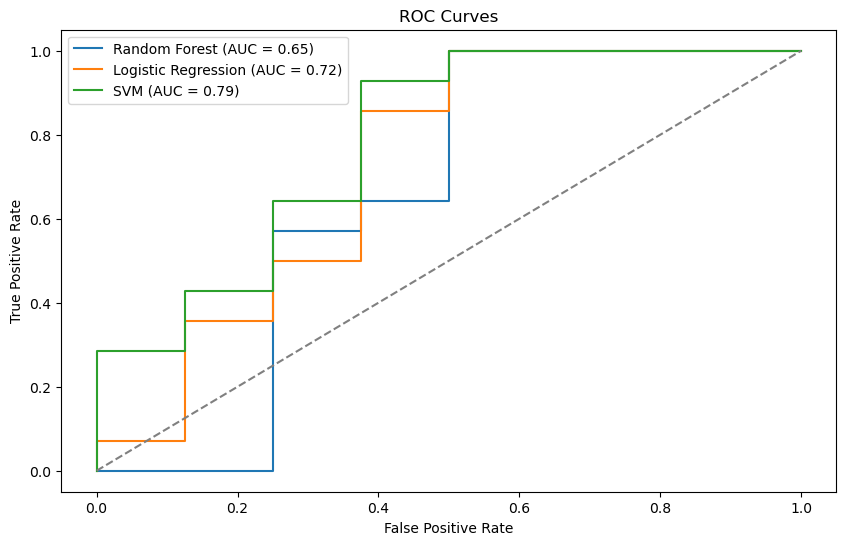

ROC curves saved to 'roc_curves.png'


In [35]:

# probs_dict = {
#     'Random Forest': rf_probs,
#     'Logistic Regression': lr_probs,
#     'SVM': svm_probs
# }

# Plot ROC curves
plt.figure(figsize=(10, 6))
for model, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model} (AUC = {roc_auc_score(y_test, probs_dict[model]):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
# plt.grid()
# plt.savefig("roc_curves.png")
plt.show()

print("ROC curves saved to 'roc_curves.png'")


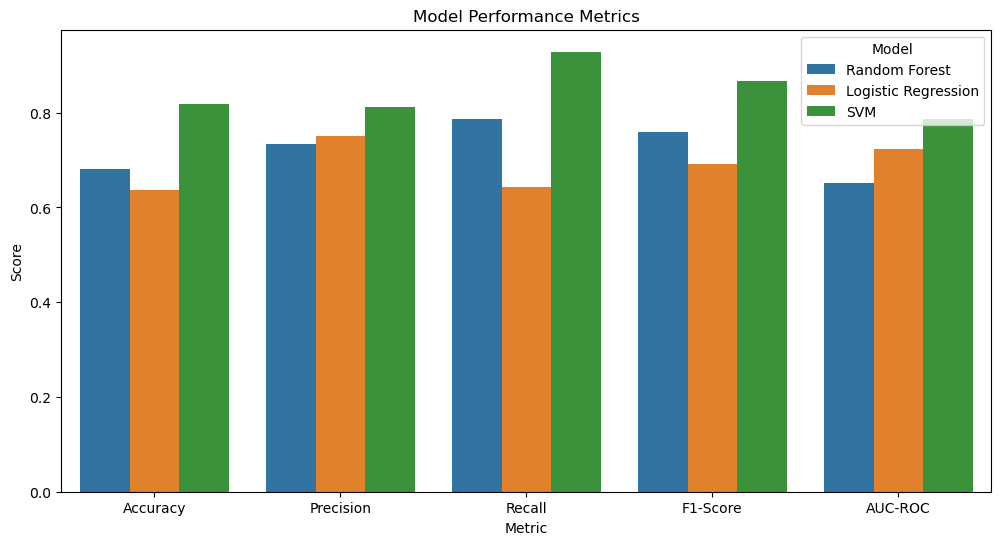

In [36]:
import seaborn as sns

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
metrics_df = results_df.melt(id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="Metric", y="Value", hue="Model")
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
# plt.savefig("model_metrics_comparison.png")
plt.show()


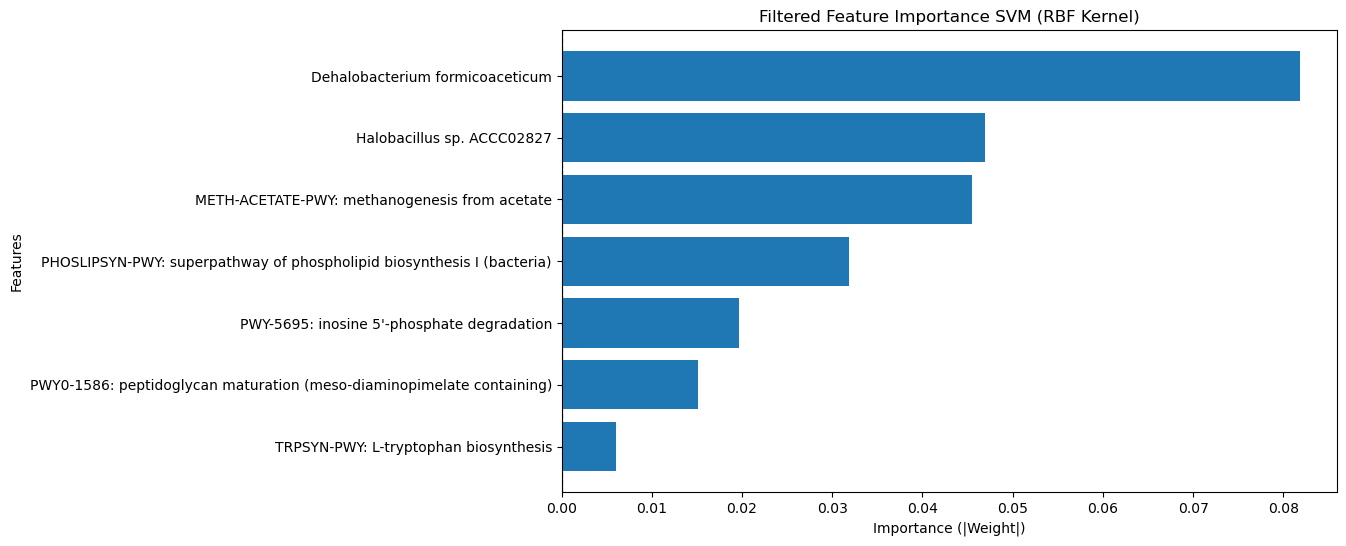

In [37]:
# import numpy as np
import matplotlib.pyplot as plt

threshold = 0.005

# Sort features by importance at a threshold
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
sorted_features = [X.columns[i] for i in sorted_idx]
sorted_importance = perm_importance.importances_mean[sorted_idx]

# Filter out features with importance below the threshold
filtered_features = [feature for feature, importance in zip(sorted_features, sorted_importance) if importance >= threshold]
filtered_importance = [importance for importance in sorted_importance if importance >= threshold]


# Plot filtered feature importance
plt.figure(figsize=(10, 6))
plt.barh(filtered_features, filtered_importance)
plt.title("Filtered Feature Importance SVM (RBF Kernel)")
plt.xlabel("Importance (|Weight|)")
plt.ylabel("Features")
plt.axvline(x=0, color='gray', linewidth=1, linestyle='--')  # Add vertical line at x = 0
plt.gca().invert_yaxis()  # Invert y-axis for descending order
# plt.gcf().set_size_inches(20,6)
# plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.savefig("feature_importance.png")
plt.show()
